<a target="_blank" href="https://colab.research.google.com/github/LPolyakova/Linear_Algebra_for_CS_students/blob/main/CP/LA_CP_05_Euclidean_spaces.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# ЛА-Практика програмування-05. Евклідові простори

In [1]:
# these imports may be useful

import pandas as pd
from scipy import linalg
from scipy.spatial.distance import pdist, cdist
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


 #### Деякі інструменти, які стануть у нагоді 

In [2]:
# these tools may be useful

# inner product
e1 = np.array([1,2,2])
e2 = np.array([2,3,-4])
p = np.dot(e1, e2)
print(f'''Inner product of vectors e1={e1} and e2={e2} is {p}''')
print('___________________________________')

# calculate distance between points
metric = 'cosine'
d = cdist([e1], [e2], metric=metric) #array of pairwise distances, here of the shape (1,1) 
print(f'''The {metric} distance between e1={e1} and e2={e2} is  {d[0][0]}''')
print('___________________________________')


# vector norm, matrix norm
A = np.array([[1,1], [0,1]])
e1_norm = np.linalg.norm(e1) # default Euclidean norm
A_norm = np.linalg.norm(A)   # default Frobenius norm
print(f'''Euclidean norm of e1={e1} is {e1_norm}. \n Frobenius norm of A={A} is {A_norm}''')
print('___________________________________')


# qr decomposition
B = np.array([[1, 2, 2, 0], [1, 1, -6, 1], [3, 2, 1, 1]]) #originally have three 4-vectors.
Bt = B.T  #write them as columns of a matrix
q, r = np.linalg.qr(Bt)
print(f'''QR-decomposition of {Bt} is Q={q}, R={r}. \n
It means that the columns of Q form the orthonormal basis of the space spanned by original vectors''')


Inner product of vectors e1=[1 2 2] and e2=[ 2  3 -4] is 0
___________________________________
The cosine distance between e1=[1 2 2] and e2=[ 2  3 -4] is  1.0
___________________________________
Euclidean norm of e1=[1 2 2] is 3.0. 
 Frobenius norm of A=[[1 1]
 [0 1]] is 1.7320508075688772
___________________________________
QR-decomposition of [[ 1  1  3]
 [ 2  1  2]
 [ 2 -6  1]
 [ 0  1  1]] is Q=[[-0.33333333 -0.36514837  0.77067464]
 [-0.66666667 -0.54772256 -0.49543369]
 [-0.66666667  0.73029674  0.11009638]
 [-0.         -0.18257419  0.38533732]], R=[[-3.          3.         -3.        ]
 [ 0.         -5.47722558 -1.64316767]
 [ 0.          0.          1.81659021]]. 

It means that the columns of Q form the orthonormal basis of the space spanned by original vectors


## Вправи

💻  **5.1. Ортонормований базис.** Напишіть функцію, яка перевіряє, чи є базис, що його дано на вході, ортонормованим. Напишіть функцію, яка розкладає даний вектор за  даним ортонормованим базисом, шукаючи його проекції на базисні вектори за допомогою скалярних добутків. Протестуйте свої функції. Для тестування можна використовувати дані з задач математичного практикуму.

In [ ]:
#write your code here

💻  **5.2. Алгоритм Грама-Шмідта.**  Напишіть програму, яка здійснює для даної системи векторів (довільної кількості) у $\mathbb{R}^4$ процес ортогоналізації та виводить ортонормований базис лінійної оболонки даних векторів. Порівняйте свої результати з QR-розкладом матриці, що складається з координат даних векторів. Для знаходження QR-розкладу можна використовувати numpy.linalg.qr або scipy.linalg.qr.

In [ ]:
#write your code here

💻  **5.3. Матриця проекції.** Напишіть функцію, яка обчислює матрицю ортогональної проекції на підпростір, натягнутий на дані вектори. Протестуйте цю функцію на прикладах (можна взяти приклади з математичного практикуму). Проілюструйте дію функції.

In [ ]:
#write your code here

💻  **5.4. Розв'язання трикутників.** Напишіть програму, яка за заданими трьома точками площини (або тривимірного простору) 
1) Малює трикутник з вершинами у даних точках.
2) Обчислює довжини сторін трикутника.
3) Обчислює кути трикутника.

Використайте вбудовані функції, що обчислюють норми векторів та скалярні добутки. Також можна використати вбудовану функцію scipy.spatial.distance.pdist, що обчислює попарні відстані між точками й видає їх у вигляді списку або (якщо додатково застосувати функцію  squareform) у вигляді матриці.

# Аналіз трикутника: пояснення

**Вхідні дані:**

Задані три точки у вигляді списку:

\[
\begin{bmatrix}
x_1 & y_1 \\
x_2 & y_2 \\
x_3 & y_3
\end{bmatrix}
\]

(або з координатами у просторі, тобто 3D).



### 1. Малювання трикутника

- Якщо точки задано у 2D, програма будує графік з підписаними вершинами.
- Трикутник малюється як ламана: `P1 → P2 → P3 → P1`, щоб замкнути контур.



### 2. Обчислення довжин сторін

- Використовується функція `pdist` з пакету `scipy` для обчислення попарних евклідових відстаней.
- Функція `squareform` перетворює список відстаней у симетричну матрицю.
- Сторони трикутника позначаються так:
  - `a = |P2 - P3|`
  - `b = |P1 - P3|`
  - `c = |P1 - P2|`



### 3. Обчислення кутів трикутника

- Для обчислення кута використовується формула косинуса:

cos(θ) = (b² + c² - a²) / (2bc)
де `a` — протилежна сторона до кута `θ`.

- Кути переводяться з радіан у градуси за допомогою `np.degrees`.
- Результат округлюється до двох знаків після коми.



✅ Після виконання функції виводяться:
- Довжини сторін трикутника.
- Значення трьох внутрішніх кутів (у градусах).
- Якщо координати 2D — також графік трикутника.


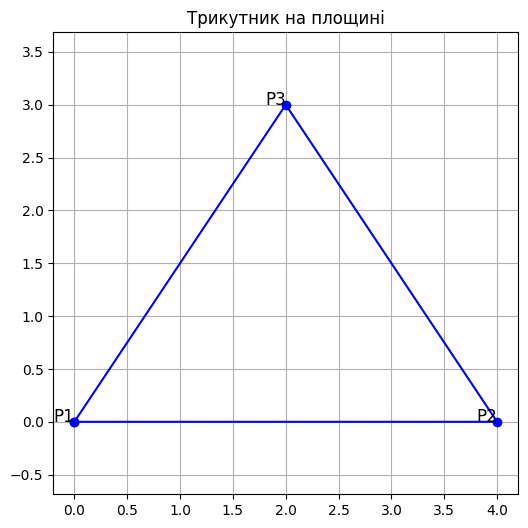


Довжини сторін трикутника:
a = |P2 - P3| = 3.6056
b = |P1 - P3| = 3.6056
c = |P1 - P2| = 4.0000

Кути трикутника (в градусах):
∠P1 = 56.31°
∠P2 = 56.31°
∠P3 = 67.38°


In [2]:
#write your code here
import pandas as pd
from scipy import linalg
from scipy.spatial.distance import pdist, squareform
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

def triangle_properties(points):
    """
    points: масив 3x2 або 3x3 (координати трьох точок на площині або у просторі)
    """

    # Перетворення у NumPy-масив
    points = np.array(points, dtype=float)

    # Перевірка розмірності
    if points.shape != (3, 2) and points.shape != (3, 3):
        print("Помилка: потрібно ввести рівно три точки у 2D або 3D.")
        return

    # 1) Малювання трикутника (для 2D)
    if points.shape[1] == 2:
        x = np.append(points[:, 0], points[0, 0])
        y = np.append(points[:, 1], points[0, 1])
        plt.figure(figsize=(6, 6))
        plt.plot(x, y, 'bo-')
        for i, (xi, yi) in enumerate(points):
            plt.text(xi, yi, f'P{i+1}', fontsize=12, ha='right')
        plt.title("Трикутник на площині")
        plt.grid(True)
        plt.axis('equal')
        plt.show()

    # 2) Обчислення довжин сторін
    dists = pdist(points)              # попарні відстані у вигляді списку
    dist_matrix = squareform(dists)   # симетрична матриця відстаней
    a = dist_matrix[1, 2]  # сторона між точками 2 і 3
    b = dist_matrix[0, 2]  # сторона між точками 1 і 3
    c = dist_matrix[0, 1]  # сторона між точками 1 і 2

    print("\nДовжини сторін трикутника:")
    print(f"a = |P2 - P3| = {a:.4f}")
    print(f"b = |P1 - P3| = {b:.4f}")
    print(f"c = |P1 - P2| = {c:.4f}")

    # 3) Обчислення кутів (косинусна теорема)
    def angle(opposite, side1, side2):
        cos_theta = (side1**2 + side2**2 - opposite**2) / (2 * side1 * side2)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)  # обмеження на випадок похибок
        theta_rad = np.arccos(cos_theta)
        return np.degrees(theta_rad)

    alpha = angle(a, b, c)  # ∠P1
    beta  = angle(b, a, c)  # ∠P2
    gamma = angle(c, a, b)  # ∠P3

    print("\nКути трикутника (в градусах):")
    print(f"∠P1 = {alpha:.2f}°")
    print(f"∠P2 = {beta:.2f}°")
    print(f"∠P3 = {gamma:.2f}°")

# Приклад використання
points_2d = [
    [0, 0],   # P1
    [4, 0],   # P2
    [2, 3]    # P3
]

triangle_properties(points_2d)


💻  **5.5. Що більше метрик, то краще.** Відстань між точками у просторі можна вимірювати не лише за допомогою евклідової метрики. Хоча лише евклідова метрика має природній вираз через скалярний добуток. Поекспериментуйте з різними метриками, що їх пропонує обчислювати модуль scipy.spatial.distance. Навчиться ними користуватися, зрозумійте їх геометричний зміст. Намалюйте в кожній з метрик одиничне коло, тобто множину точок, що знаходяться на відстані 1 від початку координат. Зверніть увагу на те, що ці "кола" не обов'язково круглі. 

In [3]:
#write your code here

## Задачі

In [4]:
# import section

🧩 **5.6. Лінійна регресія.** У цій задачі ми спробуємо побудувати модель, яка дозволить передбачувати індекс жиру людини (так званий BFI або  body fat index), який дорівнює відстотку жиру в тілі людини. Згідно з медичиними дослідженнями індекс жиру людини розраховується за формулою ${\rm BFI} = 100 (\frac{4.57}{\rho} - 4.142)$, де  $\rho$ -- густина тіла людини. Спосіб знаходження густини (ще з часів Архімеда) передбачає повне занурення людини у рідину (воду) з подальшим вимірюванням об'єму витісненої рідини. Це не дуже зручний спосіб (особливо для людини, що її пхають у воду), тому можна піти іншим шляхом і змоделювати індекс BFI, маючи у розпоряджені виміри людини, що знаходяться простішим чином. Ми побудуємо модель лінійної залежності  BFI  від таких параметрів людини як вага (weight) у кілограмах, зріст (height), окружність талії (abdomen), окружність бедер (hip), окружність шиї (neck) у сантиметрах. Дані для побудови моделі можна завантажити з файлу data\BFI.xlsx. Дані вказано для жінок, отже, якщо ви потім захочете скористатися побудованою моделлю, то майте на увазі, що для чоловіків вона не спрацює.

In [34]:
df_bfi = pd.read_excel('data\\BFI.xlsx')
df_bfi

,Weight,Height,Abdomen,Neck,Hip,BFI
0,55,150,64,34,90,22
1,80,179,70,42,95,16
2,80,161,75,38,100,28
3,54,164,62,33,89,17
4,90,158,75,38,100,29
5,70,165,71,35,99,26
6,85,156,80,40,112,37
7,52,170,61,32,90,16
8,63,160,74,37,96,26
9,49,162,59,30,88,17


1️⃣ Розглянемо модель лінійної залежності $\overline{BFI} = \theta_0+\theta_1 w+\theta_2 l+\theta_3 a+\theta_4 n +\theta_5 h$ з невідомим вектором коефіцієнтів $\Theta = (\theta_0, \dots, \theta_5)$. Підставте дані для змінних $w, l, a, n, h$, а також значення цільової змінної BFI до попереднього рівняння та отримайте матрицю $A$ й вектор правої частини $y$ у системі $A\Theta = y$ для знаходження невідомого вектора $\Theta$. З'ясуйте, чи має ця система розв'язок? Обережно: матриця системи не є квадратною, отже, стандартний np.linalg.solve для знаходження розв'язку не спрацює.

In [35]:
#write your code here

✔️ Ваші міркування запишіть тут.

2️⃣ Оскільки точного розв'язку не знайшлося, то будемо шукати найкращий розв'язок за допомогою методу найменших квадратів. Для цього домножимо обидві боки системи на матрицю $A^t$ та побудуємо так звану нормальну систему $A^tA\Theta = A^t y$ для знаходження вектора $\Theta$. Визначте матрицю $A^tA$ та вектор правої частини $A^t y$ цієї системи. Розв'яжіть нормальну систему (наприклад, за допомогою np.linalg.solve) і знайдіть вектор $\Theta$.

In [36]:
#write your code here

3️⃣ Знайдемо розв'язок ще одним способом. Нехай $A=QR$ -- QR-розклад матриці $A$. Підставте вираз для $A$ в нормальну систему й спростіть вирази. Скористайтеся тим, що матриця $Q$ має ортонормовані стовпці (отже, $Q^tQ=$ чому?), а матриця $R$ -- невироджена верхньотрикутна. Зі спрощеної системи виразіть вектор $\Theta$ через $Q, R, y$. Поміркуйте над тим, чи буде такий спосіб обчислення $\Theta$ кращим порівняно зі стандартними методами розв'язання нормальної системи (методом Гауса або через LU-розклад). У яких випадках?

✔️ Ваші міркування запишіть тут.

4️ Обчисліть QR-розклад матриці $A$ й знайдіть  $\Theta$. Порівняйте з тим розв'язком, що ви знайшли його вище.

In [37]:
#write your code here


5️⃣ Тепер скористайтеся стандартним класом LinearRegression для побудови моделі лінійної регресії з пакету sklearn.linear_model.
Атририбути reg.intercept_, reg.coef_, що ви їх отримаєте після того, як модель буде побудовано -- це шукані коефцієнти моделі $\theta_0$ та $(\theta_1, \dots, \theta_5)$ відповідно. Якщо ви все зробили вірно, то вони мають співпасти з тими, що ви знайшли вище. Таким чином, тепер ви знаєте, що знаходиться "під капотом" у вбудованих методів побудови лінійних моделей.

In [38]:
reg = linear_model.LinearRegression()
# use reg.fit() to build the model

🧩 **5.7. TF-IDF пошук документів.**

У цій задачі ми подивимося на один із засобів пошуку релевантних документів за ключовими словами серед певної множини документів (так званого корпусу).

Підхід, який ми використаємо, грунтується на обчисленні двох мір, які характеризують, наскільки часто зустрічаються ті чи інші ключові слова в документах.
Ці міри мають назви TF(Term Frequency) та IDF(Inverse Document Frequency). Ми розглянемо їх визначення, а також дію на "іграшковому"  прикладі. Замість ключових слів у нас будуть букви(символи), а замість документів -- рядки символів.

Міра TF вимірює, наскільки часто зустрічається конкретне слово в конкретному документі, і визначається як доля даного слова серед усіх слів документу:
$$TF(word, document) = \frac{number\ of\ 'word'\ in\ document}{total\  number\ of\ words\ in\ document}$$

Наприклад, ми можемо визначити міру TF для символів та рядків в такий спосіб

In [39]:
docs = ['ababagalamaga',
        'abracadabra',
        'baccara',
        'gml' ]

symbols = ['a', 'b', 'c', 'd', 'g', 'l', 'm', 'r']

#term frequency
def tf(s, doc):
    '''Returns the term frequency of the symbol s in the string doc'''
    return doc.count(s) / len(doc)

print(f'''Symbol '{symbols[0]}' has TF {round(tf(symbols[0], docs[0]), 3)} in document '{docs[0]}' ''')

Symbol 'a' has TF 0.538 in document 'ababagalamaga' 


На відміну від міри TF, яка визначає, наскільки важливим є певне слово в документі, міра IDF слідкує за тим, чи не є це слово "занадто уживаним", а отже, й таким, що не несе багато змісту (наприклад, як прийменники або артіклі).  IDF рахує відношення кількості усіх документів корпусу до кількості тих, що містять певне слово. З технічних причин зручніше додавати 1 у знаменнику (бо якщо слово не зустрічається в жодному з документів, то в знаменнику опиниться 0) і в чисельнику (подумайте, чому), а також розглядати логарифм цієї величини, збільшений на 1.

$$IDF(word, corpus) = \log\frac{number\ of\ documents\ in\ corpus + 1}{number\ of\ documents\ with\ 'word' + 1} + 1.$$

Для корпусу букв та рядків IDF можна обчислити в такий спосіб

In [40]:
#inverse document frequency
def idf(s, docs):
    '''Returns the inverse document frequency of the symbol s in the corpus of strings docs'''
    num_docs_with_s = np.sum([(s in doc) for doc in docs])
    return np.log((len(docs) + 1) / (num_docs_with_s + 1)) + 1 

print(f'''Symbol '{symbols[4]}' has IDF {round(idf(symbols[4], docs), 3)} in the corpus''')

Symbol 'g' has IDF 1.511 in the corpus


Тепер ми можемо визначити підсумкову міру кожного ключового слова в кожному документі корпусу як
$$TF\_IDF(word, document, corpus) = TF(word, document) \cdot IDF(word, corpus)$$

А також "векторизувати"  кожен документ, співставивши йому вектор значень  TF_IDF для певного списку ключових слів (або ж усіх слів, які зустрічаються в документах).

In [41]:
#vector model of a doc
def tf_idf_vector_model(doc, symbols, docs):
    '''Returns the tf-idf vector model of a string doc within set of symbols and corpus of strings docs'''
    return np.array([tf(s, doc)*idf(s, docs) for s in symbols])

# 
def tf_idf_matrix(symbols, docs):
    '''Returns the tf-idf vector models for all strings from docs'''
    return np.array([tf_idf_vector_model(doc, symbols, docs) for doc in docs])

T = tf_idf_matrix(symbols, docs)

print(f'''T={T}''')
print(f'''The  rows of matrix T correspond to vector TF_IDF presentation of documents by symbols from {symbols}.''')

T=[[0.65861576 0.18817593 0.         0.         0.23243471 0.11621736
  0.11621736 0.        ]
 [0.55597434 0.22238974 0.13734778 0.17420825 0.         0.
  0.         0.27469557]
 [0.52420438 0.17473479 0.43166446 0.         0.         0.
  0.         0.21583223]
 [0.         0.         0.         0.         0.50360854 0.50360854
  0.50360854 0.        ]]
The  rows of matrix T correspond to vector TF_IDF presentation of documents by symbols from ['a', 'b', 'c', 'd', 'g', 'l', 'm', 'r'].


Тепер, якщо нас цікавить документ, який найкраще підходить до певного ключового слова (або списку слів), то ми можемо здійснити пошук вектора, в якому сума відповідних до списку ключових слів компонент найбільша.  

In [42]:
key_symbols_index = [1, 2]

def find_best_document(key_symbols_index, symbols, docs):
    '''Returns the most relevant string from docs for the list of symbols key_symbols_index'''
    T_matrix = tf_idf_matrix(symbols, docs) #TF_IDF matrix of documents
    score = np.zeros(len(docs))             # scores of key words
    for i in key_symbols_index:
        score = score + T_matrix.T[i]
    best_document_index = np.argmax(score)  # index of maximum score
    return docs[best_document_index]

key_symbols = [symbols[i] for i in key_symbols_index]
print(f'''The best document relevant to {key_symbols} is '{find_best_document(key_symbols_index, symbols, docs)}' ''')

The best document relevant to ['b', 'c'] is 'baccara' 


1️⃣ Після довгого пояснення та прикладів час братися до роботи. Ви маєте реалізувати TF-IDF пошук для справжнього корпусу документів.
Створіть корпус документів з певної галузі знань. Документів має бути чимало (хоча б 20), при цьому не обов'язково, щоб вони були довгими --  вистачить декілька речень. Найкраще, якщо це будуть документи, які мають відношення до вашого навчання. Наприклад, шпаргалки, що містять означення та основні факти з лінійної алгебри. Ви можете використати штучний інтелект для полегшення своєї роботи, створити документи зі статей Вікіпедії, знайти готові корпуси документів на Kaggle, тощо. Документи, створені англійською мовою, обробляти буде простіше, адже англійські іменники мають менше форм, ніж українські. Надрукуйте кілька документів (чи їх фрагментів).

In [43]:
#write your code here

2️⃣ Створіть список ключових слів, які зустрічаються у документах (або використайте всі слова, що там є). Напишіть функції, що обчислюють TF, IDF, TF-IDF та векторне представлення документів за допомогою TF-IDF з урахуванням створеного списку слів. Зверніть увагу, що ваша задача складніша, ніж у випадку символів та рядків, адже вам треба попередньо обробити тексти документів таким чином, щоб розбити їх лише на слова (без знаків), записані лише маленькими літерами, і щоб ці слова зустрічалися в деякій стандартній формі (наприклад, називний відмінок однини для іменників). 

In [44]:
#write your code here

3️⃣ Напишіть функцію, яка знаходить кілька (кількість ви задаєте самі) найбільш релевантних документів за даним списком ключових слів (це мають бути слова, які зустрічаються в списку слів, використаному при побудові векторної моделі корпусу). Мірою релевантності має бути сума всіх TF-IDF- характеристик, що відповідають заданим ключовим словам.  Протестуйте вашу функцію. Чи може вона видавати шпаргалки з потрібними означеннями та теоремами за вашими запитами?

In [45]:
#write your code here

4️ Порівнюючи тексти між собою, часто використовують так звану косинусну відстань. Для двох векторів $u, v$ косинусна відстань між ними обчислюється як $$d_{cos}(u,v)=1-cos(u,v)=1-\frac{u\cdot v}{\|u\|\cdot \|v\|}.$$

Треба зазначити, що у строгому математичному сенсі косинусна відстань не є метрикою. Математики називають метрикою (або відстанню) функцію двох векторів $d(u,v)$, яка задовольняє такі умови для довільних векторів $u, v, w$:

1) Додатна визначенність: $d(u,v)\geq 0$, причому $d(u, v)=0$ в тому і лише тому випадку, коли  $u=v$.
2) Симетричність: $d(u,v)=d(v,u)$.
3) Нерівність трикутника: $d(u,v)\leq d(u,w)+d(w,v)$.

Дослідіть, які з цих властивостей має косинусна відстань, а які ні. Яких значень може набувати косинусна відстань? Що можна сказати про вектори, якщо косинусна відстань між ними мінімальна? максимальна?

Термін "відстань" використовують для $d_{cos}(u,v)$ тому, що вона має певні зв'язки з евклідовою відстанню ($d_{eucl}$). А саме для нормованих векторів (тобто таких, норма яких дорівнює 1 ) виконано рівність $(d_{eucl}(u,v))^2=2d_{cos}(u,v)$, тобто косинусна відстань пропорційна квадрату евклідової відстані. Доведіть цю тотожність.

✔️ *Ваші міркування запишіть тут.*

5️⃣ Використайте косинусну відстань для того, щоб знайти документи, що найбільш релевантні деякому запиту. Для цього за заданим запитом обчисліть його TF-IDF векторне представлення, використовуючи той самий список ключових слів, що ви його створили для побудови векторного подання документів корпусу. IDF характеристики ключових слів можна не перераховувати наново, а взяти ті, що розраховано для корпусу.

Потім серед усіх документів корпусу оберіть так званих "найближчих сусідів" -- такі документи, що їх векторні представлення знаходяться найближче (з точки зору косинусної відстані) до вектора запиту. Кількість найближчих сусідів ви задаєте самі.

Порівняйте результати дії функцій, що ви їх написали в цьому пункті та в пункті 3️⃣

In [46]:
#write your code here

✔️ Ваші міркування запишіть тут.


6️⃣ Додатково. Вбудований клас TfidfTransformer з пакету sklearn.feature_extraction.text виконує перетворення документів у вектори за допомогою TF-IDF. Ви можете поекспериментувати з ним та порівняти з тим, що отримали ви.